In [1]:
# Standard library imports
import os
import json

# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image
import cv2
import matplotlib.image as mpimg  # For loading images

# Machine learning libraries
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras import layers, models
import numpy as np
import random
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [2]:
def create_dummy_image():
    dummy_image_path = "nosample.png" 
    if os.path.exists(dummy_image_path):
        return mpimg.imread(dummy_image_path)
    else:
        print(f"Warning: '{dummy_image_path}' not found. Using a blank dummy image.")
        return np.ones((100, 100, 3), dtype=np.uint8) * 255


In [3]:
# Define the directory containing the labeled dataset
directory = r'C:\Users\david\Desktop\project\dataset\Labeled'

# Initialize an empty list to store data
data = []

# Iterate through all files in the directory
for file in os.listdir(directory):
    if file.lower().endswith('.jpg'):
        image_path = os.path.join(directory, file)
        json_path = image_path.replace('.jpg', '.json')
        
        label = None
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    content = json.load(f)
                    shapes = content.get('shapes', [])
                    if shapes and isinstance(shapes, list):
                        label = shapes[0].get('label')
            except Exception as e:
                print(f"Error reading {json_path}: {e}")
        
        data.append({'filename': image_path, 'label': label})

df = pd.DataFrame(data)
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  428 non-null    object
 1   label     428 non-null    object
dtypes: object(2)
memory usage: 6.8+ KB
None


,filename,label
0,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
1,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
2,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
3,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
4,C:\Users\david\Desktop\project\dataset\Labeled...,good


In [4]:
df.label.value_counts()

label
good           162
no_good        116
exc_solder      81
spike           38
poor_solder     31
Name: count, dtype: int64

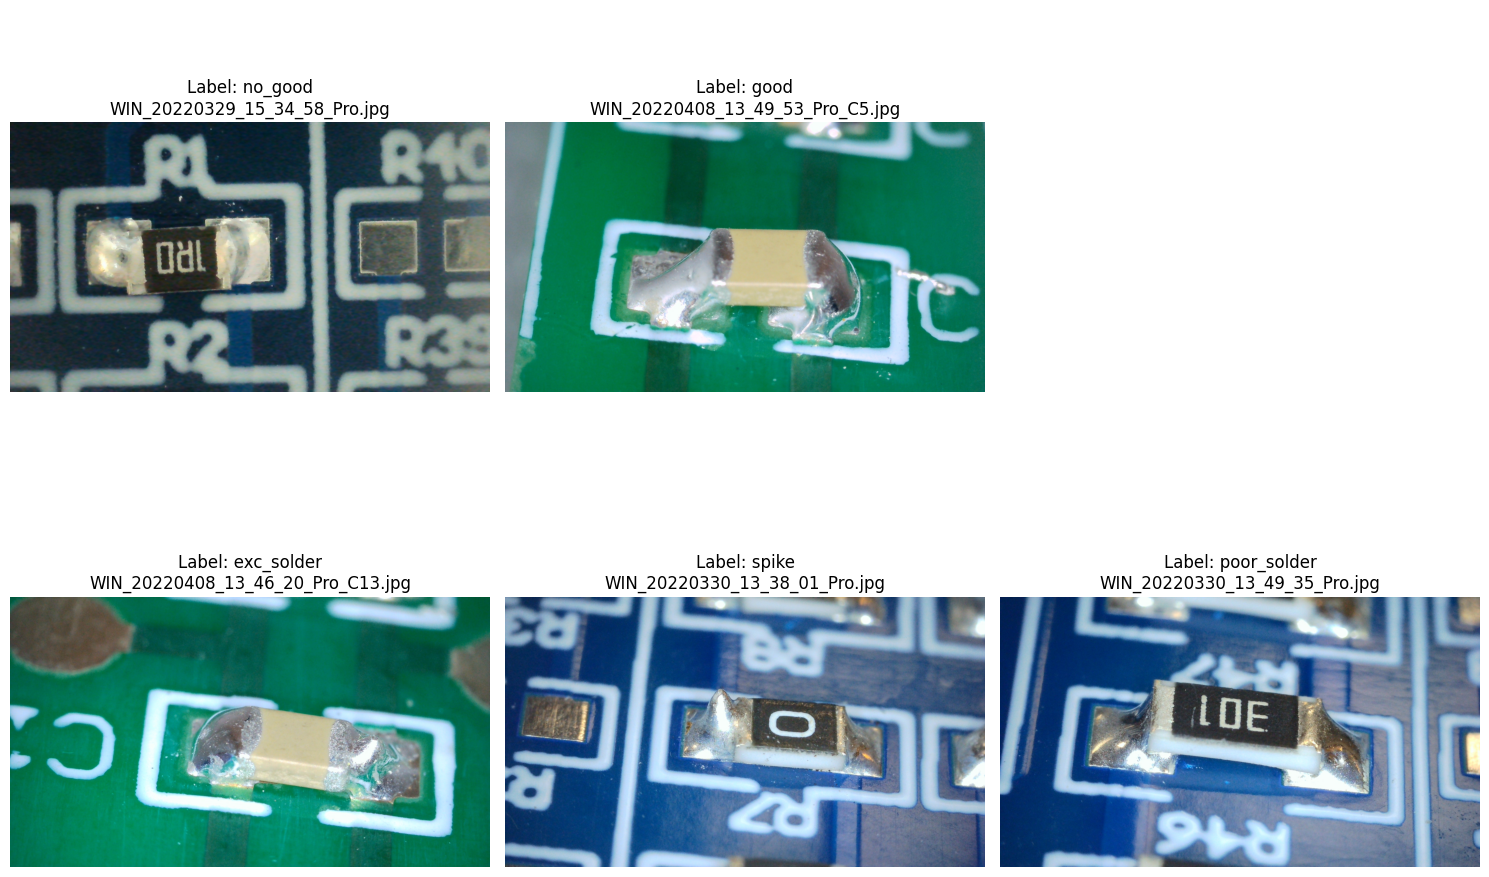

In [5]:
# Define subplot mapping for labels
subplot_mapping = {
    "no_good": (0, 0),
    "good": (0, 1),
    "exc_solder": (1, 0),
    "spike": (1, 1),
    "poor_solder": (1, 2)
}

# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Iterate through each label and its subplot position
for label, (row, col) in subplot_mapping.items():
    ax = axes[row, col]
    group = df[df['label'] == label]
    
    if not group.empty:
        # Sample one image from the group
        sample = group.sample(n=1).iloc[0]
        image_path = sample['filename']
        
        try:
            # Load and display the image
            image = Image.open(image_path)
            ax.imshow(image)
        except Exception as e:
            # Display error message if image loading fails
            ax.text(0.5, 0.5, f"Error loading image:\n{e}", ha='center', va='center')
    else:
        # Display message if no image is found for the label
        ax.text(0.5, 0.5, "No image found", ha='center', va='center')
    
    # Set title and turn off axis
    ax.set_title(f"Label: {label}\n{os.path.basename(sample['filename']) if not group.empty else ''}")
    ax.axis('off')

# Turn off unused subplot axes if there are fewer than 6 unique labels
used_positions = set(subplot_mapping.values())
for r in range(2):
    for c in range(3):
        if (r, c) not in used_positions:
            axes[r, c].axis('off')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In [21]:
# Create CNN model
def create_cnn_model():
    model = models.Sequential([
        layers.Input(shape=(224, 224, 1)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [22]:
# Self-supervised pretraining task (rotation prediction)
def create_self_supervised_data(images):
    rotations = [0, 90, 180, 270]
    x_self, y_self = [], []
    for img in images:
        img = tf.image.resize(img, (224, 224))  # Ensure consistent dimensions
        for i, angle in enumerate(rotations):
            rotated = tf.image.rot90(img, k=i)
            x_self.append(rotated.numpy())
            y_self.append(i)
    return np.array(x_self), np.array(y_self)

# Data augmentation for self-supervised learning
def augment_self_supervised_data(x_self, y_self):
    datagen = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1
    )
    augmented_x, augmented_y = [], []
    for img, label in zip(x_self, y_self):
        img = np.expand_dims(img, axis=0)
        for _ in range(2):  # Generate 2 augmented samples per image
            for aug_img in datagen.flow(img, batch_size=1):
                augmented_x.append(aug_img[0])
                augmented_y.append(label)
                break
    return np.array(augmented_x), np.array(augmented_y)

In [23]:
def create_few_shot_dataset(x_train, y_train, n_shots=5):
    few_shot_x, few_shot_y = [], []
    y_train = np.array(y_train)  # Ensure y_train is a NumPy array
    unique_classes = np.unique(y_train)
    label_to_int = {label: idx for idx, label in enumerate(unique_classes)}
    for class_label in unique_classes:
        class_indices = np.where(y_train == class_label)[0]
        if len(class_indices) == 0:
            print(f"Warning: No samples found for class {class_label}. Skipping.")
            continue
        selected_indices = np.random.choice(class_indices, n_shots, replace=len(class_indices) < n_shots)
        few_shot_x.extend(x_train[selected_indices])
        few_shot_y.extend([label_to_int[class_label]] * len(selected_indices))
    return np.array(few_shot_x), np.array(few_shot_y)

In [24]:
# Policy Network class
class PolicyNetwork:
    def __init__(self, base_model):
        self.base_model = base_model
        self.optimizer = Adam(learning_rate=0.0001)
        self.buffer_size = 64
        self.state_buffer, self.action_buffer, self.reward_buffer = [], [], []

    def get_action(self, state, training=False):
        state = tf.convert_to_tensor(state[np.newaxis, ...], dtype=tf.float32)
        logits = self.base_model(state, training=False)
        if training and random.random() < 0.1:  # 10% chance to explore
            action = random.randint(0, logits.shape[-1] - 1)
        else:
            action = tf.argmax(logits[0]).numpy()
        return int(action), logits[0]

    # Update the train_step method in the PolicyNetwork class
    @tf.function
    def train_step(self, states, actions, rewards):
        states, actions, rewards = map(tf.convert_to_tensor, [states, actions, rewards])
        with tf.GradientTape() as tape:
            logits = self.base_model(states, training=True)
            num_actions = logits.shape[-1]  # Dynamically get the number of actions (e.g., 4)
            probs = tf.nn.softmax(logits)  # Normalize logits
            action_masks = tf.one_hot(actions, num_actions)  # Use the correct number of actions
            log_probs = tf.reduce_sum(action_masks * tf.math.log(probs + 1e-10), axis=1)
            loss = -tf.reduce_mean(log_probs * rewards)
        grads = tape.gradient(loss, self.base_model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.base_model.trainable_variables))
        return loss

In [25]:
# MNIST Environment class
class MNISTEnvironment:
    def __init__(self, x_data, y_data):
        self.x_data = tf.convert_to_tensor(x_data)
        self.y_data = tf.convert_to_tensor(y_data)
        self.current_index, self.episode_reward = 0, 0
        self.max_steps = len(x_data)

    def reset(self):
        self.current_index, self.episode_reward = 0, 0
        return self.x_data[self.current_index]

    def step(self, action):
        true_label = self.y_data[self.current_index]
        reward = 5.0 if action == true_label else -0.1
        self.episode_reward += reward
        self.current_index += 1
        done = self.current_index >= self.max_steps
        next_state = self.x_data[self.current_index] if not done else None
        return next_state, reward, done, true_label

In [26]:
df.head()

,filename,label
0,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
1,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
2,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
3,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
4,C:\Users\david\Desktop\project\dataset\Labeled...,good


In [27]:
df_filtered = df[~df['label'].isin(['good', 'no_good'])].copy().reset_index(drop=True)
print(df_filtered.shape)
display(df_filtered.head())


(150, 2)


,filename,label
0,C:\Users\david\Desktop\project\dataset\Labeled...,exc_solder
1,C:\Users\david\Desktop\project\dataset\Labeled...,poor_solder
2,C:\Users\david\Desktop\project\dataset\Labeled...,spike
3,C:\Users\david\Desktop\project\dataset\Labeled...,poor_solder
4,C:\Users\david\Desktop\project\dataset\Labeled...,poor_solder


In [32]:
from sklearn.preprocessing import LabelEncoder

def load_data():
    x_data = []
    y_data = []

    for _, row in df_filtered.iterrows():
        try:
            # Load image, resize, and normalize pixel values to [0, 1]
            image = Image.open(row['filename']).convert('L')
            image = image.resize((224, 224))  # Resize to smaller dimensions
            image = np.array(image, dtype=np.float32) / 255.0  # Ensure float32 type
            x_data.append(image)

            # Use the original label as a string
            label = row['label']
            y_data.append(label)
        except Exception as e:
            print(f"Error loading image {row['filename']}: {e}")

    x_data = np.expand_dims(np.array(x_data), axis=-1)  # Add channel dimension

    # Encode string labels to integers
    label_encoder = LabelEncoder()
    y_data = label_encoder.fit_transform(y_data)

    # Split into training and testing datasets
    x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42)
    return (x_train, y_train), (x_test, y_test), label_encoder

In [33]:
# Load and preprocess data
(x_train, y_train), (x_test, y_test), label_encoder = load_data()


In [34]:
# 1. Self-supervised pre-training
x_self, y_self = create_self_supervised_data(x_train)  # Increase from 1000 to 5000 samples
self_supervised_model = create_cnn_model()
self_supervised_model.fit(x_self, y_self, epochs=10, batch_size=32, validation_split=0.2)

# Augment self-supervised data
x_self, y_self = augment_self_supervised_data(x_self, y_self)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7444 - loss: 0.8570 - val_accuracy: 0.4167 - val_loss: 1.2576
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7444 - loss: 0.8570 - val_accuracy: 0.4167 - val_loss: 1.2576
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 980ms/step - accuracy: 0.9911 - loss: 0.0221 - val_accuracy: 0.2500 - val_loss: 1.7596
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 980ms/step - accuracy: 0.9911 - loss: 0.0221 - val_accuracy: 0.2500 - val_loss: 1.7596
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9770 - loss: 0.0638 - val_accuracy: 0.2500 - val_loss: 1.7057
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9770 - loss: 0.0638 - val_accuracy: 0.2500 - val_loss: 1.7057
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9969 - loss: 0.0075 - val_accuracy: 0.3958 - val_loss: 1.3530
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9969 - loss: 0.0075 - val_accuracy: 0.3958 - val

In [35]:
# 2. Few-shot learning
few_shot_x, few_shot_y = create_few_shot_dataset(x_train, y_train, n_shots=5)
base_model = create_cnn_model()
base_model.set_weights(self_supervised_model.get_weights())
base_model.fit(few_shot_x, few_shot_y, epochs=5, batch_size=32, validation_split=0.2)

# Fine-tune the CNN model after few-shot learning
base_model.fit(few_shot_x, few_shot_y, epochs=3, batch_size=32, validation_split=0.2, verbose=1)

# Reduce learning rate for fine-tuning
base_model.compile(optimizer=Adam(learning_rate=0.0001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Fine-tune on the entire training dataset
base_model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2, verbose=1)


Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.4167 - loss: 19.9103 - val_accuracy: 1.0000 - val_loss: 0.0983
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.4167 - loss: 19.9103 - val_accuracy: 1.0000 - val_loss: 0.0983
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.4167 - loss: 12.6916 - val_accuracy: 1.0000 - val_loss: 0.1486
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.4167 - loss: 12.6916 - val_accuracy: 1.0000 - val_loss: 0.1486
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.5833 - loss: 3.7409 - val_accuracy: 1.0000 - val_loss: 0.1951
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.5833 - loss: 3.7409 - val_accuracy: 1.0000 - val_loss: 0.1951
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.7500 - loss: 1.7220 - val_accuracy: 1.0000 - val_loss: 0.2036
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.7500 - loss: 1.7220 - val_accuracy: 1.0000 - val_loss: 0.2036
Ep

Training RL:   0%|          | 0/150 [00:00<?, ?it/s]


Early stopping at episode 6


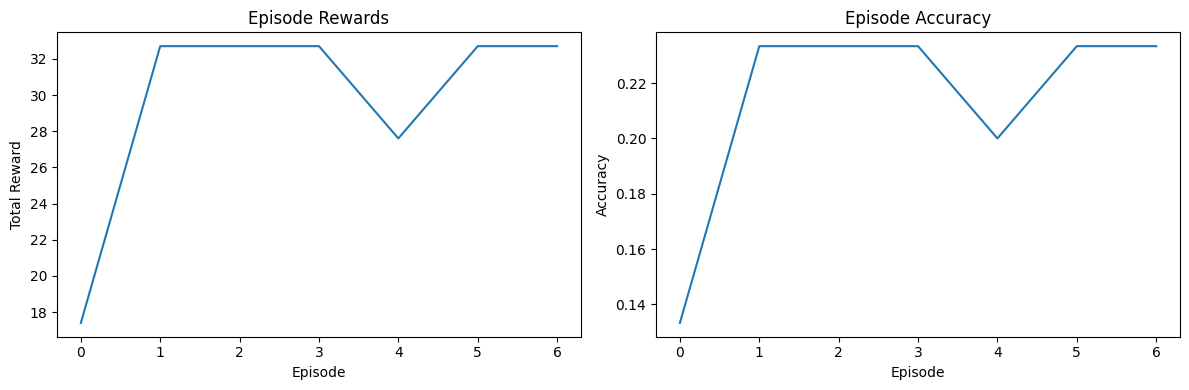

In [37]:
# 3. Policy Network RL training
env = MNISTEnvironment(x_test[:1000], y_test[:1000])  # Reduce samples
policy = PolicyNetwork(base_model)
policy.buffer_size = 64  # Increase batch size

episodes = 150  # Increase from 100 to 150
rewards_history = []
accuracy_history = []
best_accuracy = 0
patience = 7  # Adjust patience to 7
patience_counter = 0

progress_bar = tqdm(range(episodes), desc="Training RL")

# Training loop
for episode in progress_bar:
    state = env.reset()
    done = False
    episode_loss = 0
    correct_predictions = 0
    total_predictions = 0

    while not done:
        action, _ = policy.get_action(state, training=True)
        next_state, reward, done, true_label = env.step(action)
        
        # Store experience
        policy.state_buffer.append(state)
        policy.action_buffer.append(action)
        policy.reward_buffer.append(reward)
        
        # In the training loop, when updating
        if len(policy.state_buffer) >= policy.buffer_size:
            states = np.array(policy.state_buffer, dtype=np.float32)
            actions = np.array(policy.action_buffer, dtype=np.int32)
            rewards = np.array(policy.reward_buffer, dtype=np.float32)
            
            loss = policy.train_step(states, actions, rewards)
            episode_loss += loss
            
            # Clear buffers
            policy.state_buffer = []
            policy.action_buffer = []
            policy.reward_buffer = []
        
        if action == true_label:  # Compare action with the original string label
            correct_predictions += 1
        total_predictions += 1
        
        if not done:
            state = next_state
    
    episode_accuracy = correct_predictions / total_predictions
    rewards_history.append(env.episode_reward)
    accuracy_history.append(episode_accuracy)
    
    # Early stopping
    patience = 5  # Reduce from 10 to 5
    min_delta = 0.01  # Add minimum improvement threshold

    # In the training loop
    if episode_accuracy > best_accuracy + min_delta:
        best_accuracy = episode_accuracy
        patience_counter = 0
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"\nEarly stopping at episode {episode}")
        break
    
    progress_bar.set_postfix({
        'reward': f'{env.episode_reward:.2f}',
        'acc': f'{episode_accuracy:.2%}',
        'loss': f'{float(episode_loss):.2f}'
    })

# Add learning rate decay for policy network
policy.optimizer.learning_rate = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=50,
    decay_rate=0.96
)

# Plot training results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(rewards_history)
plt.title('Episode Rewards')
plt.xlabel('Episode')
plt.ylabel('Total Reward')

plt.subplot(1, 2, 2)
plt.plot(accuracy_history)
plt.title('Episode Accuracy')
plt.xlabel('Episode')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()


In [42]:
# Final evaluation
correct = 0
total = 0
for x, y in zip(x_test, y_test):
    action, _ = policy.get_action(x)
    if action == y:
        correct += 1
    total += 1

print(f"Final Test Accuracy: {correct/total:.2%}")

# Convert numeric labels back to original string labels
original_labels = label_encoder.inverse_transform(y_test)
predicted_labels = label_encoder.inverse_transform([policy.get_action(x)[0] for x in x_test])


Final Test Accuracy: 23.33%


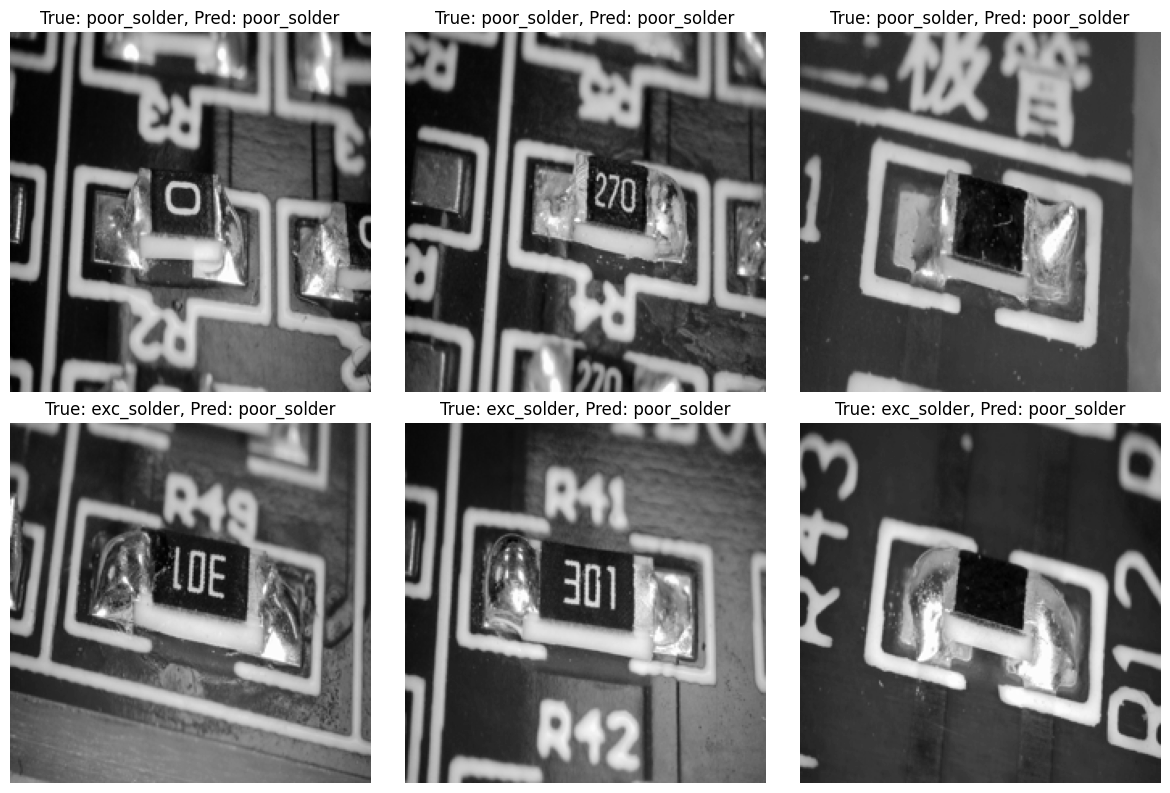

In [41]:
# Error analysis: Display 3 correct and 3 incorrect predictions
import random

# Collect correct and incorrect predictions
correct_predictions = []
incorrect_predictions = []

for x, y in zip(x_test, y_test):
    action, _ = policy.get_action(x)
    if action == y:
        correct_predictions.append((x, label_encoder.inverse_transform([y])[0], label_encoder.inverse_transform([action])[0]))
    else:
        incorrect_predictions.append((x, label_encoder.inverse_transform([y])[0], label_encoder.inverse_transform([action])[0]))

# Randomly select 3 correct and 3 incorrect predictions
correct_samples = random.sample(correct_predictions, 3)
incorrect_samples = random.sample(incorrect_predictions, 3)

# Plot the results
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Display correct predictions on the top row
for i, (img, true_label, pred_label) in enumerate(correct_samples):
    axes[0, i].imshow(img.squeeze(), cmap='gray')
    axes[0, i].set_title(f"True: {true_label}, Pred: {pred_label}")
    axes[0, i].axis('off')

# Display incorrect predictions on the bottom row
for i, (img, true_label, pred_label) in enumerate(incorrect_samples):
    axes[1, i].imshow(img.squeeze(), cmap='gray')
    axes[1, i].set_title(f"True: {true_label}, Pred: {pred_label}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()